In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

def set_korean_font():
    candidates = [
        "Apple SD Gothic Neo",
        "AppleGothic",
        "NanumGothic",
        "Malgun Gothic",
        "Noto Sans CJK KR",
        "Noto Sans KR"
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            print(f"[OK] font set to: {name}")
            return
    print("[WARN] Korean font not found. Labels may break.")

set_korean_font()

[OK] font set to: Apple SD Gothic Neo


1) 데이터 로드 + Transaction 추출

In [2]:
import pandas as pd
import numpy as np

# raw 로드
profile = pd.read_json("../data/raw/profile.json", orient="records", lines=True)
transcript = pd.read_json("../data/raw/transcript.json", orient="records", lines=True)

print(profile.shape, transcript.shape)

# transaction 이벤트만
tx = transcript[transcript["event"] == "transaction"].copy()

# 금액 추출
tx["amount"] = tx["value"].apply(lambda x: x.get("amount") if isinstance(x, dict) else np.nan)

print("tx rows:", len(tx), "amount na:", tx["amount"].isna().mean().round(4))
tx.head()

(17000, 5) (306534, 4)
tx rows: 138953 amount na: 0.0


,person,event,value,time,amount
12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0,0.83
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0,34.56
12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0,13.23
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0,19.51
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0,18.97


2) 가입월(cohort_month) 만들기

In [3]:
profile = profile.copy()
profile["became_member_on"] = pd.to_datetime(
    profile["became_member_on"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

profile["cohort_month"] = profile["became_member_on"].dt.to_period("M")
profile[["id", "became_member_on", "cohort_month"]].head()

,id,became_member_on,cohort_month
0,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,2017-02
1,0610b486422d4921ae7d2bf64640c50b,2017-07-15,2017-07
2,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,2018-07
3,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,2017-05
4,a03223e636434f42ac4c3df47e8bac43,2017-08-04,2017-08


3) transaction에 cohort 붙이기


In [4]:
tx_cohort = tx.merge(
    profile[["id", "cohort_month"]],
    left_on="person",
    right_on="id",
    how="left"
)

print("tx_cohort rows:", len(tx_cohort), "cohort_month na:", tx_cohort["cohort_month"].isna().mean().round(4))
tx_cohort.head()

tx_cohort rows: 138953 cohort_month na: 0.0


,person,event,value,time,amount,id,cohort_month
0,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0,0.83,02c083884c7d45b39cc68e1314fec56c,2016-07
1,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0,34.56,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,2016-01
2,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0,13.23,54890f68699049c2a04d415abc25e717,2017-12
3,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0,19.51,b2f1cd155b864803ad8334cdf13c4bd2,2017-10
4,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0,18.97,fe97aa22dd3e48c8b143116a8403dd52,2017-12


4) “거래 월(transaction_month)” 만들기 (중요: 상대시간 기반)

⚠️ transcript의 time은 “0~714시간” 같은 상대시간이라
절대적인 달력 월은 의미가 없어.
그래서 우리는 **‘경과 시간’을 월 단위로 “인덱스화”**만 한다.

✅ 가장 안전하고 단순한 방법: 30일 = 720시간으로 월 버킷화

In [6]:
# 1주 = 7일 = 168시간
tx_cohort["txn_week_index"] = (tx_cohort["time"] // (24 * 7)).astype(int)

tx_cohort["txn_week_index"].describe()

count    138953.000000
mean          1.815470
std           1.202195
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: txn_week_index, dtype: float64

In [7]:
# cohort 기준: 첫 거래 주
tx_cohort["cohort_week"] = (
    tx_cohort
    .groupby("person")["txn_week_index"]
    .transform("min")
)

# 코호트 경과 주
tx_cohort["cohort_age_week"] = (
    tx_cohort["txn_week_index"] - tx_cohort["cohort_week"]
)

In [8]:
# 코호트 테이블
cohort_counts = (
    tx_cohort
    .groupby(["cohort_week", "cohort_age_week"])["person"]
    .nunique()
    .reset_index(name="active_users")
)

cohort_pivot = cohort_counts.pivot_table(
    index="cohort_week",
    columns="cohort_age_week",
    values="active_users"
)

In [9]:
# retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

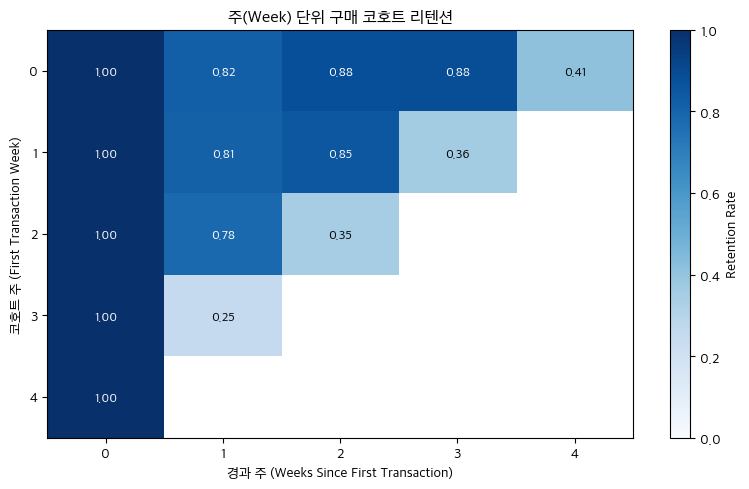

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.imshow(retention, aspect="auto", cmap="Blues", vmin=0, vmax=1)

# 축 설정
plt.xticks(
    ticks=np.arange(len(retention.columns)),
    labels=retention.columns
)
plt.yticks(
    ticks=np.arange(len(retention.index)),
    labels=retention.index
)

plt.xlabel("경과 주 (Weeks Since First Transaction)")
plt.ylabel("코호트 주 (First Transaction Week)")
plt.title("주(Week) 단위 구매 코호트 리텐션")

# 🔥 수치 표시 핵심 부분
for i in range(retention.shape[0]):
    for j in range(retention.shape[1]):
        value = retention.iloc[i, j]
        if not np.isnan(value):
            plt.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="black" if value < 0.7 else "white",
                fontsize=9
            )

plt.colorbar(label="Retention Rate")
plt.tight_layout()
plt.show()

📊 주(Week) 단위 구매 코호트 리텐션 분석

1️⃣ 분석 목적

본 분석은
첫 구매 이후 고객이 얼마나 지속적으로 재구매하는지를
시간 경과에 따라 파악하기 위해 수행되었다.

특히,
	•	구매 이후 초기 이탈이 언제 집중적으로 발생하는지
	•	신규 코호트일수록 리텐션 구조가 어떻게 달라지는지

를 확인하는 것을 목표로 한다.

⸻

2️⃣ 분석 기준 및 방법

📌 분석 단위
	•	개인(person) 단위

📌 코호트 정의
	•	고객의 첫 구매가 발생한 주(Week) 를 기준으로 코호트를 구성
	•	cohort_week = 첫 transaction 발생 시점 (주 단위)

📌 경과 기간 정의
	•	첫 구매 이후 경과한 주 수
	•	weeks_since_first_txn = 현재 거래 주 - 첫 거래 주

📌 리텐션 정의
	•	각 코호트에서
해당 주차에 1회 이상 구매한 고객 비율
	•	Week 0은 코호트 기준 주이므로 리텐션 100%로 고정

📌 시각화 방식
	•	행(row): 첫 구매 주 기준 코호트
	•	열(column): 첫 구매 이후 경과 주
	•	값(value): 주차별 리텐션 비율
	•	히트맵 + 수치(annotation)로 직관적 비교 가능

⸻

3️⃣ 분석 결과 요약

📌 전반적 패턴
	•	모든 코호트에서
Week 0 → Week 1 구간에서 가장 큰 리텐션 하락이 발생
	•	이후 주차에서는
이미 잔존한 고객 위주로 비교적 완만한 감소 또는 유지 패턴을 보임

📌 코호트별 차이
	•	초기 코호트(0~1주):
	•	Week 1 리텐션: 약 0.8 이상
	•	후반 코호트(3~4주):
	•	Week 1 리텐션이 0.25 수준까지 급락
	•	신규 코호트일수록
첫 구매 이후 유지력이 더 낮은 구조가 관찰됨

⸻

4️⃣ 핵심 해석

🔴 ① 이탈은 ‘장기 사용 문제’가 아니라 ‘초기 경험 문제’
	•	리텐션 하락이 장기 구간이 아닌
첫 구매 직후 1주 이내에 집중
	•	이는 고객이 서비스를 충분히 경험하기도 전에
이탈 여부가 결정되고 있음을 의미

🔴 ② 신규 유입 고객일수록 구조적으로 취약
	•	최근 코호트일수록 초기 리텐션이 급격히 낮아짐
	•	이는 단순한 개인 성향이 아니라,
초기 오퍼·온보딩·조건 설계의 구조적 문제 가능성을 시사

🔴 ③ 리텐션 자체보다 ‘왜 떠나는가’가 더 중요
	•	코호트 분석은
이탈이 발생하는 시점과 규모를 보여주는 도구
	•	하지만
이탈의 원인(소득, 오퍼 조건, 난이도, 신규 여부 등) 은 설명하지 못함

⸻

5️⃣ 분석의 한계 및 다음 단계

⚠️ 한계
	•	본 코호트 분석은
	•	구매 여부만을 기준으로 한 결과이며
	•	고객 속성이나 오퍼 조건을 반영하지 않음

🔜 다음 단계
	•	본 코호트 결과를 근거로
이탈 예측 모델(Drop-off Prediction Model) 을 구축하여
	•	누가
	•	어떤 조건에서
	•	왜 초기 이탈하는지
를 정량적으로 분석할 필요가 있음

⸻

🧠 한 줄 요약 (발표용)

주 단위 구매 코호트 분석 결과,
이탈은 장기 사용 이전의 문제가 아니라
첫 구매 직후 1주 이내에 결정되는 초기 구조적 문제로 나타났다.